In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated, Literal
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
import os 

In [3]:
load_dotenv()

True

In [4]:
model = ChatOpenAI(
    model="openai/gpt-oss-20b",
    api_key=os.getenv("GROQ_API_KEY"),
    base_url= os.getenv("GROQ_BASE_URL"),
    max_tokens=1000,
    temperature=0.5
)

In [5]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [6]:
def generate_joke(state: JokeState):

    prompt = f"Generate a joke on the topic {state['topic']}"
    response = model.invoke(prompt).content

    return {'joke': response}

In [8]:
def generate_explanation(state: JokeState):

    prompt = f"Write an explanation for the joke - {state['joke']}"
    response = model.invoke(prompt).content

    return {'explanation': response}

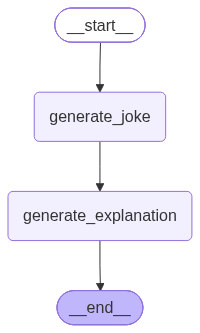

In [ ]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer )

workflow

In [24]:
config2 = {
    "configurable": {"thread_id":2}
}


workflow.invoke({"topic":"Indian education system"}, config=config2)

{'topic': 'Indian education system',
 'joke': 'Why did the student bring a ladder to the Indian exam?\n\nBecause the teacher said the questions were *above* the students’ heads!',
 'explanation': '**Explanation of the joke**\n\nThe joke hinges on a classic *word‑play* (a pun) between a literal and a figurative meaning of the phrase **“above the students’ heads.”**\n\n1. **Figurative meaning**  \n   In everyday English (and in many Indian classrooms, too), a teacher might say that a question or a concept is *“above the students’ heads”* to mean that it is **too difficult** or **beyond their current level of understanding**. It’s a metaphorical way of saying the material is “higher” than what the students can grasp.\n\n2. **Literal interpretation**  \n   The student takes the teacher’s comment **literally**: the questions are physically *above* their heads, so to reach them the student needs a **ladder**. The image of a student literally climbing a ladder to answer exam questions is absu

In [25]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'Indian education system', 'joke': 'Why did the student bring a ladder to the Indian exam?\n\nBecause the teacher said the questions were *above* the students’ heads!', 'explanation': '**Explanation of the joke**\n\nThe joke hinges on a classic *word‑play* (a pun) between a literal and a figurative meaning of the phrase **“above the students’ heads.”**\n\n1. **Figurative meaning**  \n   In everyday English (and in many Indian classrooms, too), a teacher might say that a question or a concept is *“above the students’ heads”* to mean that it is **too difficult** or **beyond their current level of understanding**. It’s a metaphorical way of saying the material is “higher” than what the students can grasp.\n\n2. **Literal interpretation**  \n   The student takes the teacher’s comment **literally**: the questions are physically *above* their heads, so to reach them the student needs a **ladder**. The image of a student literally climbing a ladder to answer exa

In [26]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Indian education system', 'joke': 'Why did the student bring a ladder to the Indian exam?\n\nBecause the teacher said the questions were *above* the students’ heads!', 'explanation': '**Explanation of the joke**\n\nThe joke hinges on a classic *word‑play* (a pun) between a literal and a figurative meaning of the phrase **“above the students’ heads.”**\n\n1. **Figurative meaning**  \n   In everyday English (and in many Indian classrooms, too), a teacher might say that a question or a concept is *“above the students’ heads”* to mean that it is **too difficult** or **beyond their current level of understanding**. It’s a metaphorical way of saying the material is “higher” than what the students can grasp.\n\n2. **Literal interpretation**  \n   The student takes the teacher’s comment **literally**: the questions are physically *above* their heads, so to reach them the student needs a **ladder**. The image of a student literally climbing a ladder to answer ex

## Time Travel

In [30]:
workflow.get_state(
    {
        "configurable": {
            "thread_id":2,
            'checkpoint_id': '1f1af68b-56ff-6530-8000-122c7ac7fa81'
        }
    }
)

StateSnapshot(values={'topic': 'Indian education system'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f1af68b-56ff-6530-8000-122c7ac7fa81'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-09-13T11:46:08.066884+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1af68b-56fd-62df-bfff-a2c1263095b7'}}, tasks=(PregelTask(id='1f4b0b66-30e2-90fe-2d01-e7e4dd047194', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the student bring a ladder to the Indian exam?\n\nBecause the teacher said the questions were *above* the students’ heads!'}),), interrupts=())

In [32]:
workflow.invoke(
    None,
    config={
        "configurable": {
            "thread_id": "2",
            "checkpoint_id": "1f1af68b-56ff-6530-8000-122c7ac7fa81"
        }
    }
)

{'topic': 'Indian education system',
 'joke': 'Why did the Indian student bring a ladder to the exam?  \n\nBecause the syllabus said “climb the grades ladder,” and he heard it literally!',
 'explanation': '**Why the joke works**\n\n1. **The set‑up**  \n   The question asks why an Indian student would bring a ladder to an exam.  \n   The answer is a punchline that turns a common phrase into a literal action.\n\n2. **The phrase “climb the grades ladder”**  \n   In many schools (especially in India) the syllabus or teachers will say something like,  \n   *“If you want to get good marks, you need to climb the grades ladder.”*  \n   It’s a **metaphor**: the “ladder” represents the path to higher grades, and “climb” means to improve or progress.\n\n3. **Literal vs. figurative language**  \n   The humor comes from the student taking the metaphor **literally**.  \n   Instead of thinking about studying harder, he thinks, “I need a ladder to actually climb.”  \n   So he brings a physical ladder 

In [33]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Indian education system', 'joke': 'Why did the Indian student bring a ladder to the exam?  \n\nBecause the syllabus said “climb the grades ladder,” and he heard it literally!', 'explanation': '**Why the joke works**\n\n1. **The set‑up**  \n   The question asks why an Indian student would bring a ladder to an exam.  \n   The answer is a punchline that turns a common phrase into a literal action.\n\n2. **The phrase “climb the grades ladder”**  \n   In many schools (especially in India) the syllabus or teachers will say something like,  \n   *“If you want to get good marks, you need to climb the grades ladder.”*  \n   It’s a **metaphor**: the “ladder” represents the path to higher grades, and “climb” means to improve or progress.\n\n3. **Literal vs. figurative language**  \n   The humor comes from the student taking the metaphor **literally**.  \n   Instead of thinking about studying harder, he thinks, “I need a ladder to actually climb.”  \n   So he bring

## Update State

In [34]:
workflow.update_state(
    {'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1af68b-56fd-62df-bfff-a2c1263095b7'}},
    {'topic':'tier-3 colleges'}
)

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1af6b3-f10d-6b96-8000-c2df74148594'}}

In [35]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'tier-3 colleges'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1af6b3-f10d-6b96-8000-c2df74148594'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-09-13T12:04:17.962673+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1af68b-56fd-62df-bfff-a2c1263095b7'}}, tasks=(PregelTask(id='f4a025f4-4fec-54e1-2a23-a96ff20c6439', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'Indian education system', 'joke': 'Why did the Indian student bring a ladder to the exam?  \n\nBecause the syllabus said “climb the grades ladder,” and he heard it literally!', 'explanation': '**Why the joke works**\n\n1. **The set‑up**  \n   The question asks why an Indian student would bring a ladder to an exam.  \n   The answer is a 

In [37]:
workflow.invoke(
    None,
    config={
        "configurable": {
            "thread_id": "2",
            "checkpoint_id": "1f1af6b3-f10d-6b96-8000-c2df74148594"
        }
    }
)

{'topic': 'tier-3 colleges',
 'joke': 'Why did the student from a tier‑3 college bring a ladder to the graduation ceremony?\n\nBecause they heard the diploma was “on a higher level” and they wanted to make sure they could actually reach it!',
 'explanation': '**Why the joke works**\n\n| Element | What it is | How it contributes to the humor |\n|---------|------------|----------------------------------|\n| **Tier‑3 college** | A school that is considered “low‑tier” or less prestigious compared to top‑tier institutions. | Sets up a contrast: the student comes from a place that’s *not* known for high status, so the idea of a “higher level” feels absurd. |\n| **“Higher level”** | A phrase that can mean two very different things. | 1. *Academic* – a higher level of study or achievement. 2. *Literal* – something that is physically higher up. The joke hinges on the double meaning. |\n| **The ladder** | A tool used to climb to a higher place. | The student interprets “higher level” literally a